In [11]:
# Cell 1: Import và cấu hình chung
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader, TensorDataset, Subset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs("figures", exist_ok=True)
sns.set_style("whitegrid")
print("Device:", DEVICE)

Device: cpu


In [12]:
# Cell 2: Tải và chia MNIST (torchvision tự tải về ./data)
from torchvision import datasets, transforms

tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_full = datasets.MNIST('./data', train=True,  download=True, transform=tf)
test_ds    = datasets.MNIST('./data', train=False, download=True, transform=tf)

train_idx, val_idx = train_test_split(
    np.arange(len(train_full)), test_size=0.10,
    random_state=SEED, stratify=train_full.targets.numpy())

train_ds = Subset(train_full, train_idx)
val_ds   = Subset(train_full, val_idx)

mnist_loaders = {
    'train': DataLoader(train_ds, batch_size=128, shuffle=True,  num_workers=2),
    'val':   DataLoader(val_ds,   batch_size=256, shuffle=False, num_workers=2),
    'test':  DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=2),
}
mnist_info = dict(in_ch=1, n_cls=10, shape=(28, 28), name='MNIST')
print(f"[MNIST] train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}")

[MNIST] train=54000, val=6000, test=10000


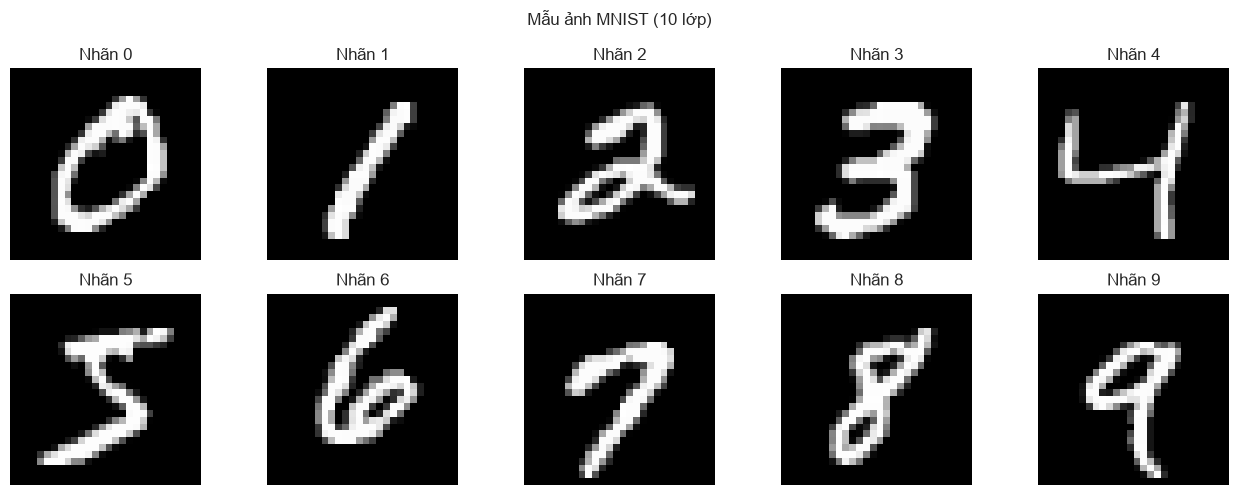

In [13]:
# Cell 3: Vẽ 10 mẫu đại diện + histogram pixel
fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for i, ax in enumerate(axes.flat):
    for idx in range(len(train_full)):
        x, y = train_full[idx]
        if y == i:
            ax.imshow(x.squeeze(), cmap='gray')
            ax.set_title(f"Nhãn {i}")
            ax.axis('off')
            break
plt.suptitle("Mẫu ảnh MNIST (10 lớp)")
plt.tight_layout()
plt.savefig("figures/eda_mnist_samples.png", dpi=200)
plt.show()

In [14]:
# Cell 4: Tải và chia CIFAR-10
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2470, 0.2435, 0.2616)

train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

cifar_train = datasets.CIFAR10('./data', train=True,  download=True, transform=train_tf)
cifar_test  = datasets.CIFAR10('./data', train=False, download=True, transform=test_tf)
cifar_train_eval = datasets.CIFAR10('./data', train=True, download=True, transform=test_tf)

tr_idx, va_idx = train_test_split(
    np.arange(len(cifar_train)), test_size=0.10,
    random_state=SEED, stratify=cifar_train.targets)

cifar_loaders = {
    'train': DataLoader(Subset(cifar_train, tr_idx),      batch_size=128, shuffle=True,  num_workers=2),
    'val':   DataLoader(Subset(cifar_train_eval, va_idx), batch_size=256, shuffle=False, num_workers=2),
    'test':  DataLoader(cifar_test,                       batch_size=256, shuffle=False, num_workers=2),
}
cifar_info = dict(in_ch=3, n_cls=10, shape=(32, 32), name='CIFAR-10')
print(f"[CIFAR-10] train={len(tr_idx)}, val={len(va_idx)}, test={len(cifar_test)}")

[CIFAR-10] train=45000, val=5000, test=10000


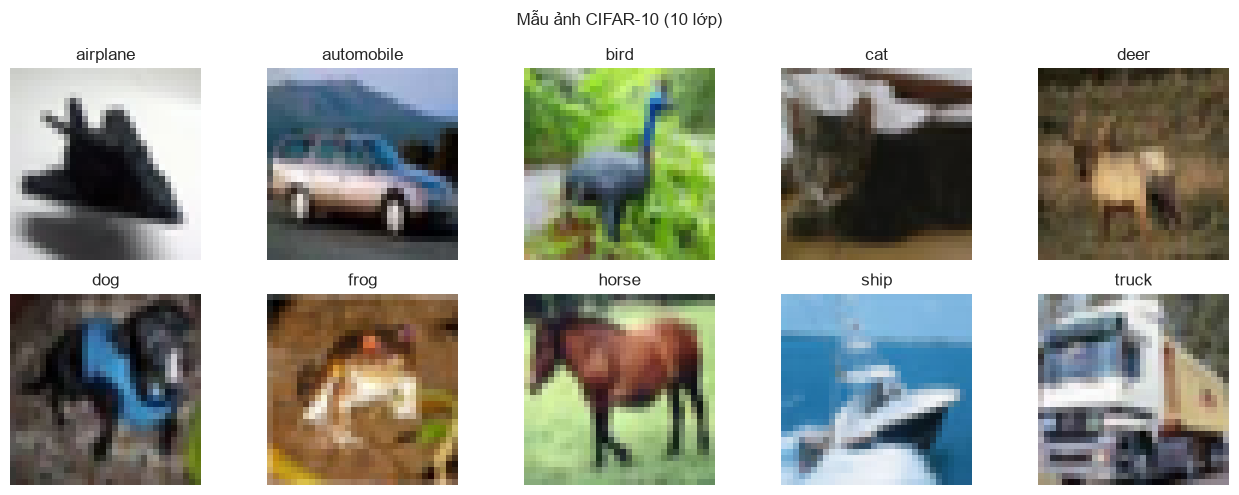

In [15]:
# Cell 5: Mẫu ảnh CIFAR-10
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']
fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for i, ax in enumerate(axes.flat):
    for idx in range(len(cifar_train_eval)):
        x, y = cifar_train_eval[idx]
        if y == i:
            img = x.permute(1,2,0).numpy()
            img = img * np.array(std) + np.array(mean)   # unnormalize
            ax.imshow(np.clip(img, 0, 1))
            ax.set_title(class_names[i])
            ax.axis('off')
            break
plt.suptitle("Mẫu ảnh CIFAR-10 (10 lớp)")
plt.tight_layout()
plt.savefig("figures/eda_cifar_samples.png", dpi=200)
plt.show()

In [16]:
# Cell 6: Đọc file diabetes.csv (đặt cùng cấp với notebook)
df = pd.read_csv("diabetes.csv")
print("Shape:", df.shape)
print(df.head())
print("\nThông tin cột:")
df.info()

Shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Thông tin cột:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose 

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

C:\Users\The Hoang\AppData\Local\Temp\ipykernel_18856\3699097533.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Outcome', ax=ax[0], palette='Blues')


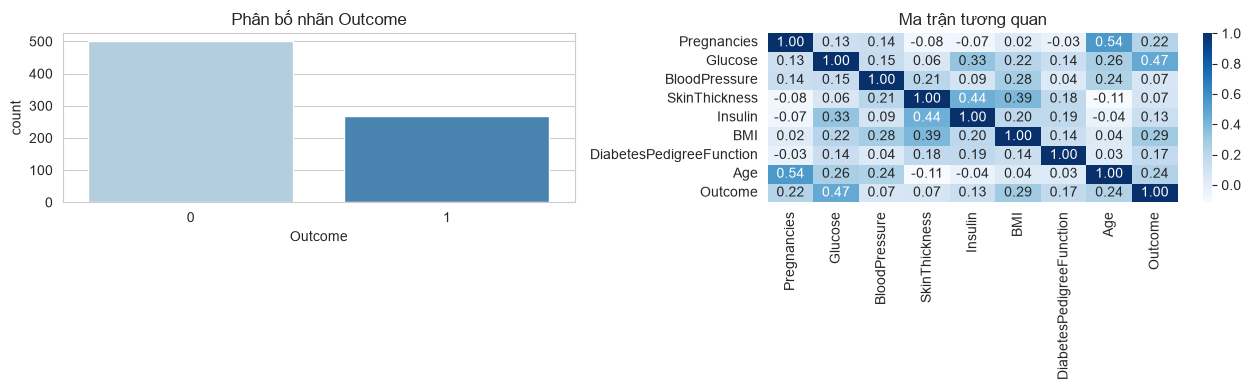

In [17]:
# Cell 7: Thống kê mô tả + phân bố nhãn + tương quan
print(df.describe())
print("\nPhân bố nhãn:")
print(df['Outcome'].value_counts())
print(df['Outcome'].value_counts(normalize=True))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=df, x='Outcome', ax=ax[0], palette='Blues')
ax[0].set_title("Phân bố nhãn Outcome")
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='Blues', ax=ax[1])
ax[1].set_title("Ma trận tương quan")
plt.tight_layout()
plt.savefig("figures/eda_diabetes.png", dpi=200)
plt.show()

In [18]:
# Cell 8: Xử lý giá trị 0 phi lý + chia tập + Impute + Scale

zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_clean = df.copy()
df_clean[zero_cols] = df_clean[zero_cols].replace(0, np.nan)

print("Số giá trị NaN sau khi đổi 0 -> NaN:")
print(df_clean.isnull().sum())

X = df_clean.drop(columns=['Outcome']).values
y = df_clean['Outcome'].values

# Chia 70/15/15 stratified
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
X_va, X_te, y_va, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

# Fit CHỈ trên train → tránh data leakage
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()
X_tr = scaler.fit_transform(imputer.fit_transform(X_tr))
X_va = scaler.transform(imputer.transform(X_va))
X_te = scaler.transform(imputer.transform(X_te))

print(f"\nTrain: {X_tr.shape} | Val: {X_va.shape} | Test: {X_te.shape}")

Số giá trị NaN sau khi đổi 0 -> NaN:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Train: (537, 8) | Val: (115, 8) | Test: (116, 8)


In [19]:
# Cell 9: Tạo DataLoader cho Conv1D — input shape (N, 1, L=8)

def to_tensor(X, y):
    Xt = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # (N, 1, L)
    yt = torch.tensor(y, dtype=torch.long)
    return TensorDataset(Xt, yt)

diabetes_loaders = {
    'train': DataLoader(to_tensor(X_tr, y_tr), batch_size=32, shuffle=True),
    'val':   DataLoader(to_tensor(X_va, y_va), batch_size=64, shuffle=False),
    'test':  DataLoader(to_tensor(X_te, y_te), batch_size=64, shuffle=False),
}

# Class weight cho bài toán mất cân bằng
cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
class_weights = torch.tensor(cw, dtype=torch.float32).to(DEVICE)
print(f"[Diabetes] Class weights: {cw}")

diabetes_info = dict(in_ch=1, n_cls=2, shape=(X_tr.shape[1],),
                     name='Diabetes', class_weights=class_weights)
print(f"[Diabetes] input shape cho Conv1D: {diabetes_info['shape']}")

[Diabetes] Class weights: [0.76714286 1.43582888]
[Diabetes] input shape cho Conv1D: (8,)


In [20]:
# Cell 10: Bảng tổng hợp
rows = [
    ["MNIST",          "Ảnh xám 28×28",  "70,000", "10", "Cân bằng",   "Conv2D"],
    ["CIFAR-10",       "Ảnh màu 32×32",  "60,000", "10", "Cân bằng",   "Conv2D"],
    ["Diabetes (Pima)","Bảng số 8 đặc trưng", "768", "2", "3:1 nhẹ",   "Conv1D"],
]
summary = pd.DataFrame(rows, columns=["Dataset", "Loại", "Số mẫu",
                                       "Số lớp", "Cân bằng", "Input Conv"])
print(summary.to_string(index=False))
summary.to_csv("results_dataset_summary.csv", index=False)

        Dataset                Loại Số mẫu Số lớp Cân bằng Input Conv
          MNIST       Ảnh xám 28×28 70,000     10 Cân bằng     Conv2D
       CIFAR-10       Ảnh màu 32×32 60,000     10 Cân bằng     Conv2D
Diabetes (Pima) Bảng số 8 đặc trưng    768      2  3:1 nhẹ     Conv1D
